# **Project: Amazon Product Recommendation System**

# **Marks: 40**


Welcome to the project on Recommendation Systems. We will work with the Amazon product reviews dataset for this project. The dataset contains ratings of different electronic products. It does not include information about the products or reviews to avoid bias while building the model.

--------------
## **Context:**
--------------

Today, information is growing exponentially with volume, velocity and variety throughout the globe. This has lead to information overload, and too many choices for the consumer of any business. It represents a real dilemma for these consumers and they often turn to denial. Recommender Systems are one of the best tools that help recommending products to consumers while they are browsing online. Providing personalized recommendations which is most relevant for the user is what's most likely to keep them engaged and help business.

E-commerce websites like Amazon, Walmart, Target and Etsy use different recommendation models to provide personalized suggestions to different users. These companies spend millions of dollars to come up with algorithmic techniques that can provide personalized recommendations to their users.

Amazon, for example, is well-known for its accurate selection of recommendations in its online site. Amazon's recommendation system is capable of intelligently analyzing and predicting customers' shopping preferences in order to offer them a list of recommended products. Amazon's recommendation algorithm is therefore a key element in using AI to improve the personalization of its website. For example, one of the baseline recommendation models that Amazon uses is item-to-item collaborative filtering, which scales to massive data sets and produces high-quality recommendations in real-time.

----------------
## **Objective:**
----------------

You are a Data Science Manager at Amazon, and have been given the task of building a recommendation system to recommend products to customers based on their previous ratings for other products. You have a collection of labeled data of Amazon reviews of products. The goal is to extract meaningful insights from the data and build a recommendation system that helps in recommending products to online consumers.

-----------------------------
## **Dataset:**
-----------------------------

The Amazon dataset contains the following attributes:

- **userId:** Every user identified with a unique id
- **productId:** Every product identified with a unique id
- **Rating:** The rating of the corresponding product by the corresponding user
- **timestamp:** Time of the rating. We **will not use this column** to solve the current problem

**Note:** The code has some user defined functions that will be usefull while making recommendations and measure model performance, you can use these functions or can create your own functions.

Sometimes, the installation of the surprise library, which is used to build recommendation systems, faces issues in Jupyter. To avoid any issues, it is advised to use **Google Colab** for this project.

Let's start by mounting the Google drive on Colab.

In [1]:
# Uninstalling numpy because sometimes this version causes problems when importing the suprise library
!pip uninstall numpy -y

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2


In [2]:
# Installing the version of numpy that won't cause us any problems during our analysis
!pip install numpy==1.26.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/17.9 MB 62.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.0 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.0 which is incompatible

**Note:** A pop-up will appear prompting you to restart the session. Please click on it, and then begin running the notebook from the cell below — not from the beginning.

In [1]:
# Import our google drive so we can pull our data directly from there into our notebook
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Installing surprise library**

In [2]:
# Now we installl the suprise library so we can import necessary functions in the next step.
!pip install surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 4.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554971 sha256=239ac1760135dff9580d9b3faf4768b4213bf2d15750413a84881ec68266bdac
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


## **Importing the necessary libraries and overview of the dataset**

In [3]:
# Import basic Python libraries
import numpy as np
import pandas as pd

# Import Python libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import for implementing matrix factorization based recommendation system
from surprise.prediction_algorithms.matrix_factorization import SVD
from collections import defaultdict

# Import for implementing cross validation
from surprise.model_selection import KFold

import warnings
warnings.filterwarnings('ignore')

### **Loading the data**
- Import the Dataset
- Add column names ['user_id', 'prod_id', 'rating', 'timestamp']
- Drop the column timestamp
- Copy the data to another DataFrame called **df**

In [4]:
# Importing the dataset
data = pd.read_csv('/content/drive/MyDrive/Data Science and Machine Learning MIT/Course 6: Recommendation Systems/Project 3/ratings_Electronics.csv')

In [5]:
# Add appropriate coulmn names to our data
data.columns = ['user_id', 'prod_id', 'rating', 'timestamp']

In [6]:
# The timestamp column won't provide us any value in our recomendation system so let's drop it.
data.drop('timestamp', axis = 1, inplace = True)

In [7]:
# Let's check the data to see if our column names have been correctly added and the timestamp column was dropped
data.head()

,user_id,prod_id,rating
0,A2CX7LUOHB2NDG,0321732944,5.0
1,A2NWSAGRHCP8N5,0439886341,1.0
2,A2WNBOD3WNDNKT,0439886341,3.0
3,A1GI0U4ZRJA8WN,0439886341,1.0
4,A1QGNMC6O1VW39,0511189877,5.0


In [8]:
# Now let's create a copy of our data to another variable to avoid making any unwanted changes to original data
df = data.copy()

In [9]:
# Check to make sure our copy contains the same data as our original data
df.head()

,user_id,prod_id,rating
0,A2CX7LUOHB2NDG,0321732944,5.0
1,A2NWSAGRHCP8N5,0439886341,1.0
2,A2WNBOD3WNDNKT,0439886341,3.0
3,A1GI0U4ZRJA8WN,0439886341,1.0
4,A1QGNMC6O1VW39,0511189877,5.0


**As this dataset is very large and has 7,824,482 observations, it is not computationally possible to build a model using this. Moreover, many users have only rated a few products and also some products are rated by very few users. Hence, we can reduce the dataset by considering certain logical assumptions.**

Here, we will be taking users who have given at least 50 ratings, and the products that have at least 5 ratings, as when we shop online we prefer to have some number of ratings of a product.

In [10]:
# Get the column containing the users
users = df.user_id

# Create a dictionary from users to their number of ratings
ratings_count = dict()

for user in users:

    # If we already have the user, just add 1 to their rating count
    if user in ratings_count:
        ratings_count[user] += 1

    # Otherwise, set their rating count to 1
    else:
        ratings_count[user] = 1

In [11]:
# We want our users to have at least 50 ratings to be considered
RATINGS_CUTOFF = 50

remove_users = []

for user, num_ratings in ratings_count.items():
    if num_ratings < RATINGS_CUTOFF:
        remove_users.append(user)

df = df.loc[ ~ df.user_id.isin(remove_users)]

In [12]:
# Get the column containing the products
prods = df.prod_id

# Create a dictionary from products to their number of ratings
ratings_count = dict()

for prod in prods:

    # If we already have the product, just add 1 to its rating count
    if prod in ratings_count:
        ratings_count[prod] += 1

    # Otherwise, set their rating count to 1
    else:
        ratings_count[prod] = 1

In [13]:
# We want our item to have at least 5 ratings to be considered
RATINGS_CUTOFF = 5

remove_users = []

for user, num_ratings in ratings_count.items():
    if num_ratings < RATINGS_CUTOFF:
        remove_users.append(user)

df_final = df.loc[~ df.prod_id.isin(remove_users)]

In [14]:
# Print a few rows of the imported dataset
df_final.head()

,user_id,prod_id,rating
1309,A3LDPF5FMB782Z,1400501466,5.0
1321,A1A5KUIIIHFF4U,1400501466,1.0
1334,A2XIOXRRYX0KZY,1400501466,3.0
1450,AW3LX47IHPFRL,1400501466,5.0
1455,A1E3OB6QMBKRYZ,1400501466,1.0


## **Exploratory Data Analysis**

### **Shape of the data**

In [15]:
# Shape of the data before size reduction
data.shape

(7824481, 3)

### **Check the number of rows and columns and provide observations.**

In [16]:
# Check the number of rows and columns after size reduction
df_final.shape

(65290, 3)

**Write your observations here:**
We can see that the final shape of our data is 3 columns (user_id, prod_id, and rating) and 65,290 rows which has decreased significantly from our 7,824,481 rows before our reduction making our data much easier to work with.

### **Data types**

In [17]:
# Check Data types of our columns
df_final.dtypes

,0
user_id,object
prod_id,object
rating,float64


In [18]:
# Checking what values are in the ratings column
df_final['rating'].value_counts()

,count
rating,
5.0,36315
4.0,18127
3.0,6481
2.0,2515
1.0,1852


In [19]:
#Checking the values in the prod_id column
df_final['prod_id'].value_counts()

,count
prod_id,
B0088CJT4U,206
B003ES5ZUU,184
B000N99BBC,167
B007WTAJTO,164
B00829TIEK,149
...,...
B00368CDH6,5
B0036AZA6A,5
B0036E8V08,5


**Write your observations here:**
We can see above the data types of our 3 columns.  user_id is of type object because the ids are a collection of letters and numbers.  We can change it to a string as we did in previous case studies in this unit.  prod_id is of type object because the ids are a collection of letters and numbers.  We can change it to a string as well.  Finally, rating is of type float but only contains discrete values of 1,2,3,4, or 5 so for consistency, we can change the type to integer as well.

In [20]:
# Changing the types of the columns as stated above
df_final['user_id'] = df_final['user_id'].astype(str)
df_final['prod_id'] = df_final['prod_id'].astype(str)
df_final['rating'] = df_final['rating'].astype(int)

### **Checking for missing values**

In [21]:
# Checking for missing values in our data
df_final.isnull().sum()

,0
user_id,0
prod_id,0
rating,0


**Write your observations here:**
From the above code we can see that we have no missing values in our data.  Therefore, the couple of values that looked to be missing earlier must have been removed during the reduction we did.

### **Summary Statistics**

In [22]:
# Summary statistics of 'rating' variable
df_final['rating'].describe()

,rating
count,65290.000000
mean,4.294808
std,0.988915
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


**Write your observations here:**
From the summary statistics we can see that:
*   ratings has 65,290 entries which is consistent with the number of rows in our data
*   ratings has an average of 4.29 which is skewed towards the higher end of the spectrum suggesting most of the ratings being fours or fives.
*   The minimum and maximum values are 1 and 5 respectively which we had seen previously
*   ratings has a median value of 5 which means that over half of the products in our set have a rating of 5.




### **Checking the rating distribution**

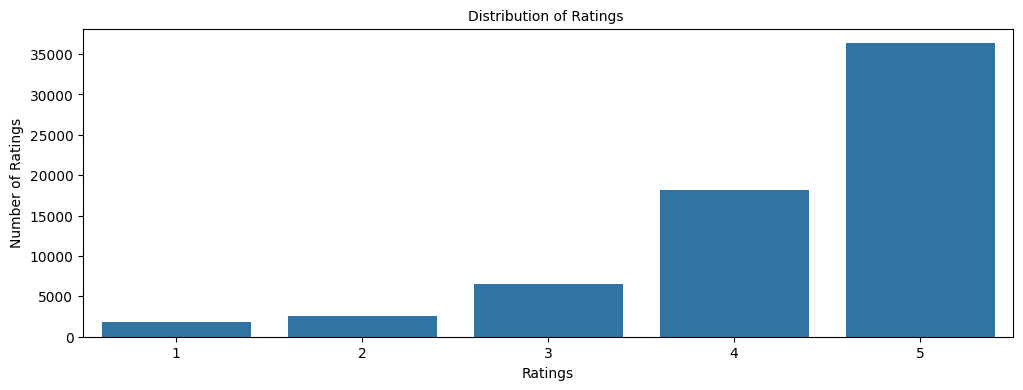

In [23]:
# Create the bar plot of distribution of ratings
plt.figure(figsize = (12, 4))
sns.countplot(x="rating", data=df_final)

plt.tick_params(labelsize = 10)
plt.title("Distribution of Ratings ", fontsize = 10)
plt.xlabel("Ratings", fontsize = 10)
plt.ylabel("Number of Ratings", fontsize = 10)
plt.show()

**Write your observations here:**
From the above plot we can see that the distribution of ratings is skewed heavily to the left, meaning that a substantial majority of our reviews lie in the 4 or 5 category (about 20 thousand and 35 thousand respectively out of our 65,290 rows of data).  We can also say that there are a small percentage of our reviews in the 1,2,or 3 categories (About 2 thousand, 3 thousand, and 6 thousand reespectively out of our 65,290 rows of data).

### **Checking the number of unique users and items in the dataset**

In [24]:
# Number of total rows in our df_final
len(df_final)

65290

In [25]:
# Number of unique users in our df_final
df_final['user_id'].nunique()

1540

In [26]:
# Number of unique products in df_final
df_final['prod_id'].nunique()

5689

**Write your observations here:**
*   There are 5,689 unique products and 1,540 unique users in our data.
*  With the number of unique users and products, there is a possibility of 5689 * 1540 = 8,761,060 ratings in the dataset.
*   We only have 65,290 ratings, so not every user has rated every product in the dataset.







### **Users with the most number of ratings**

In [27]:
# Top 10 users based on the number of ratings
df_final.groupby('user_id')['rating'].count().sort_values(ascending = False).head(10)

,rating
user_id,
ADLVFFE4VBT8,295
A3OXHLG6DIBRW8,230
A1ODOGXEYECQQ8,217
A36K2N527TXXJN,212
A25C2M3QF9G7OQ,203
A680RUE1FDO8B,196
A22CW0ZHY3NJH8,193
A1UQBFCERIP7VJ,193
AWPODHOB4GFWL,184


**Write your observations here:**
*   From here we can see that the user who has rated the most products has only rated 295 out of the possible 5,689 which is only a small percentage.
*   Because of our last two observations, we should build a recommendation system to recommend products to users which they have not interacted with yet.



**Now that we have explored and prepared the data, let's build the first recommendation system.**

## **Model 1: Rank Based Recommendation System**

In [28]:
# Calculate the average rating for each product
average_rating = df_final.groupby('prod_id')['rating'].mean()

# Calculate the count of ratings for each product
rating_count = df_final.groupby('prod_id')['rating'].count()

# Create a dataframe with calculated average and count of ratings
final_rating = pd.DataFrame({"average_rating":average_rating,"rating_count":rating_count})

# Sort the dataframe by average of ratings in the descending order
final_rating = final_rating.sort_values(by='average_rating',ascending=False)

# See the first five records of the "final_rating" dataset
final_rating.head(5)

,average_rating,rating_count
prod_id,,
B00LGQ6HL8,5.0,5
B003DZJQQI,5.0,14
B005FDXF2C,5.0,7
B00I6CVPVC,5.0,7
B00B9KOCYA,5.0,8


In [29]:
# Defining a function to get the top n products based on the highest average rating and minimum interactions
def top_n_products(data, n, min_interaction=100):

    # Finding products with minimum number of interactions
    recommendations = data[data['rating_count'] > min_interaction]
    # Sorting values with respect to average rating
    recommendations = recommendations.sort_values(by='average_rating', ascending=False)

    return recommendations.index[:n]

### **Recommending top 5 products with 50 minimum interactions based on popularity**

In [30]:
# Recommends the top 5 products with 50 minimum interactions based on popularity
top_5_products_50 = top_n_products(final_rating,5,50)
top_5_products_50

Index(['B001TH7GUU', 'B003ES5ZUU', 'B0019EHU8G', 'B006W8U2MU', 'B000QUUFRW'], dtype='object', name='prod_id')

### **Recommending top 5 products with 100 minimum interactions based on popularity**

In [31]:
# Recommends the top 5 products with 100 minimum interactions based on popularity
top_5_products_100 = top_n_products(final_rating,5,100)
top_5_products_100

Index(['B003ES5ZUU', 'B000N99BBC', 'B007WTAJTO', 'B002V88HFE', 'B004CLYEDC'], dtype='object', name='prod_id')

We have recommended the **top 5** products by using the popularity recommendation system. Now, let's build a recommendation system using **collaborative filtering.**

## **Model 2: Collaborative Filtering Recommendation System**

### **Building a baseline user-user similarity based recommendation system**

- Below, we are building **similarity-based recommendation systems** using `cosine` similarity and using **KNN to find similar users** which are the nearest neighbor to the given user.  
- We will be using a new library, called `surprise`, to build the remaining models. Let's first import the necessary classes and functions from this library.

In [32]:
# To compute the accuracy of models
from surprise import accuracy

# Class is used to parse a file containing ratings, data should be in structure - user ; item ; rating
from surprise.reader import Reader

# Class for loading datasets
from surprise.dataset import Dataset

# For tuning model hyperparameters
from surprise.model_selection import GridSearchCV

# For splitting the rating data in train and test datasets
from surprise.model_selection import train_test_split

# For implementing similarity-based recommendation system
from surprise.prediction_algorithms.knns import KNNBasic

# For implementing matrix factorization based recommendation system
from surprise.prediction_algorithms.matrix_factorization import SVD

# for implementing K-Fold cross-validation
from surprise.model_selection import KFold

# For implementing clustering-based recommendation system
from surprise import CoClustering

**Before building the recommendation systems, let's  go over some basic terminologies we are going to use:**

**Relevant item:** An item (product in this case) that is actually **rated higher than the threshold rating** is relevant, if the **actual rating is below the threshold then it is a non-relevant item**.  

**Recommended item:** An item that's **predicted rating is higher than the threshold is a recommended item**, if the **predicted rating is below the threshold then that product will not be recommended to the user**.  


**False Negative (FN):** It is the **frequency of relevant items that are not recommended to the user**. If the relevant items are not recommended to the user, then the user might not buy the product/item. This would result in the **loss of opportunity for the service provider**, which they would like to minimize.

**False Positive (FP):** It is the **frequency of recommended items that are actually not relevant**. In this case, the recommendation system is not doing a good job of finding and recommending the relevant items to the user. This would result in **loss of resources for the service provider**, which they would also like to minimize.

**Recall:** It is the **fraction of actually relevant items that are recommended to the user**, i.e., if out of 10 relevant products, 6 are recommended to the user then recall is 0.60. Higher the value of recall better is the model. It is one of the metrics to do the performance assessment of classification models.

**Precision:** It is the **fraction of recommended items that are relevant actually**, i.e., if out of 10 recommended items, 6 are found relevant by the user then precision is 0.60. The higher the value of precision better is the model. It is one of the metrics to do the performance assessment of classification models.

**While making a recommendation system, it becomes customary to look at the performance of the model. In terms of how many recommendations are relevant and vice-versa, below are some most used performance metrics used in the assessment of recommendation systems.**

### **Precision@k, Recall@ k, and F1-score@k**

**Precision@k** - It is the **fraction of recommended items that are relevant in `top k` predictions**. The value of k is the number of recommendations to be provided to the user. One can choose a variable number of recommendations to be given to a unique user.  


**Recall@k** - It is the **fraction of relevant items that are recommended to the user in `top k` predictions**.

**F1-score@k** - It is the **harmonic mean of Precision@k and Recall@k**. When **precision@k and recall@k both seem to be important** then it is useful to use this metric because it is representative of both of them.

### **Some useful functions**

- Below function takes the **recommendation model** as input and gives the **precision@k, recall@k, and F1-score@k** for that model.  
- To compute **precision and recall**, **top k** predictions are taken under consideration for each user.
- We will use the precision and recall to compute the F1-score.

In [33]:
def precision_recall_at_k(model, k = 10, threshold = 3.5):
    """Return precision and recall at k metrics for each user"""

    # First map the predictions to each user
    user_est_true = defaultdict(list)

    # Making predictions on the test data
    predictions = model.test(testset)

    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():

        # Sort user ratings by estimated value
        user_ratings.sort(key = lambda x: x[0], reverse = True)

        # Number of relevant items
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)

        # Number of recommended items in top k
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])

        # Number of relevant and recommended items in top k
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold))
                              for (est, true_r) in user_ratings[:k])

        # Precision@K: Proportion of recommended items that are relevant
        # When n_rec_k is 0, Precision is undefined. Therefore, we are setting Precision to 0 when n_rec_k is 0

        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0

        # Recall@K: Proportion of relevant items that are recommended
        # When n_rel is 0, Recall is undefined. Therefore, we are setting Recall to 0 when n_rel is 0

        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    # Mean of all the predicted precisions are calculated.
    precision = round((sum(prec for prec in precisions.values()) / len(precisions)), 3)

    # Mean of all the predicted recalls are calculated.
    recall = round((sum(rec for rec in recalls.values()) / len(recalls)), 3)

    accuracy.rmse(predictions)

    print('Precision: ', precision) # Command to print the overall precision

    print('Recall: ', recall) # Command to print the overall recall

    print('F_1 score: ', round((2*precision*recall)/(precision+recall), 3)) # Formula to compute the F-1 score

**Hints:**

- To compute **precision and recall**, a **threshold of 3.5 and k value of 10 can be considered for the recommended and relevant ratings**.
- Think about the performance metric to choose.

Below we are loading the **`rating` dataset**, which is a **pandas DataFrame**, into a **different format called `surprise.dataset.DatasetAutoFolds`**, which is required by this library. To do this, we will be **using the classes `Reader` and `Dataset`.**

In [34]:
# Instantiating Reader scale with expected rating scale
reader = Reader(rating_scale=(0,5))

# Loading the rating dataset
cf_data = Dataset.load_from_df(df_final[['user_id','prod_id','rating']],reader)

# Splitting the data into train and test datasets
trainset, testset = train_test_split(cf_data, test_size=0.2,random_state=1)

Now, we are **ready to build the first baseline similarity-based recommendation system** using the cosine similarity.

### **Building the user-user Similarity-based Recommendation System**

In [35]:
# Declaring the similarity options
sim_options = {'name': "cosine",'user_based':True}

# Initializing the KNNBasic model using sim_options declared, Verbose = False, and setting random_state = 1
user_user_sim = KNNBasic(sim_options = sim_options,verbose=False,random_state=1)

# Fitting the model on the training data
user_user_sim.fit(trainset)

# Computing precision@k, recall@k, and f_1 score using the precision_recall_at_k function defined above
precision_recall_at_k(user_user_sim)

RMSE: 1.0260
Precision:  0.844
Recall:  0.862
F_1 score:  0.853


**Write your observations here:**
*   Our initial model has a RMSE(root mean squared error) of 1.026 on our testing data
*   Our precision of .844 means that out of all recommended products about 84 are relevant.
*   Our recall of 0.862 means that out of all the relevant products about 86 percent are being recommended.
*   Our F_1 score of 0.853 is the harmonic mean of precision and recall and tells us that most recommended products are relevant and relevant products are being recommended.
*   The above metrics are what we will try to improve by tuning hyperparameters later on.







Let's now **predict rating for a user with `userId=A3LDPF5FMB782Z` and `productId=1400501466`** as shown below. Here the user has already interacted or watched the product with productId '1400501466' and given a rating of 5.

In [36]:
# Predicting rating for a sample user with an interacted product
user_user_sim.predict('A3LDPF5FMB782Z','1400501466',r_ui=5,verbose=True)

user: A3LDPF5FMB782Z item: 1400501466 r_ui = 5.00   est = 3.33   {'actual_k': 6, 'was_impossible': False}


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, est=3.3333333333333335, details={'actual_k': 6, 'was_impossible': False})

**Write your observations here:**
For this user-item pair the actual rating given to the product was a 5 but our model predicted it to be a 3.33 which is not very accurate.  We will have to tune our model and see if it can make a better prediction on this user-item pair after being tuned.

Below is the **list of users who have not seen the product with product id "1400501466"**.

In [37]:
# Find unique user_id where prod_id is not equal to "1400501466"
df_final[df_final['prod_id'] != '1400501466']['user_id'].unique()

array(['A2ZR3YTMEEIIZ4', 'A3CLWR1UUZT6TG', 'A5JLAU2ARJ0BO', ...,
       'A215WH6RUDUCMP', 'A38C12950IM24P', 'A2J4XMWKR8PPD0'], dtype=object)

* It can be observed from the above list that **user "A34BZM6S9L7QI4" has not seen the product with productId "1400501466"** as this userId is a part of the above list.

**Below we are predicting rating for `userId=A34BZM6S9L7QI4` and `prod_id=1400501466`.**

In [38]:
# Predicting rating for a sample user with a non interacted product
user_user_sim.predict('A34BZM6S9L7QI4','1400501466',verbose=True)

user: A34BZM6S9L7QI4 item: 1400501466 r_ui = None   est = 1.99   {'actual_k': 2, 'was_impossible': False}


Prediction(uid='A34BZM6S9L7QI4', iid='1400501466', r_ui=None, est=1.991150442477876, details={'actual_k': 2, 'was_impossible': False})

**Write your observations here:**
From the above prediction we can see that this user has not interacted with this item but is predicted by our model to have a rating 1.99.  From this predicted rating we can say that this particular product probably should not be recommended to the given user.

### **Improving similarity-based recommendation system by tuning its hyperparameters**

Below, we will be tuning hyperparameters for the `KNNBasic` algorithm. Let's try to understand some of the hyperparameters of the KNNBasic algorithm:

- **k** (int) – The (max) number of neighbors to take into account for aggregation. Default is 40.
- **min_k** (int) – The minimum number of neighbors to take into account for aggregation. If there are not enough neighbors, the prediction is set to the global mean of all ratings. Default is 1.
- **sim_options** (dict) – A dictionary of options for the similarity measure. And there are four similarity measures available in surprise -
    - cosine
    - msd (default)
    - Pearson
    - Pearson baseline

In [39]:
# Setting up parameter grid to tune the hyperparameters
param_grid = {'k': [20, 30, 40], 'min_k': [1, 3, 6, 9],
              'sim_options': {'name': ['msd', 'cosine','pearson'],
                              'user_based': [True]}
              }
# Performing 3-fold cross-validation to tune the hyperparameters
gs = GridSearchCV(KNNBasic, param_grid, measures=['rmse', 'mae'], cv=3, n_jobs=-1)

# Fitting the data
gs.fit(cf_data)
# Best RMSE score
print(gs.best_score['rmse'])
# Combination of parameters that gave the best RMSE score
print(gs.best_params['rmse'])

0.9697797492330421
{'k': 40, 'min_k': 6, 'sim_options': {'name': 'cosine', 'user_based': True}}


Once the grid search is **complete**, we can get the **optimal values for each of those hyperparameters**.

Now, let's build the **final model by using tuned values of the hyperparameters**, which we received by using **grid search cross-validation**.

In [40]:
# Using the optimal similarity measure for user-user based collaborative filtering
sim_options = {'name': "cosine",'user_based':True}
# Creating an instance of KNNBasic with optimal hyperparameter values
user_user_sim_optimized = KNNBasic(sim_options = sim_options,k=40,min_k=6,verbose=False,random_state=1)
# Training the algorithm on the trainset
user_user_sim_optimized.fit(trainset)
# Let us compute precision@k and recall@k also with k =10
precision_recall_at_k(user_user_sim_optimized)

RMSE: 0.9759
Precision:  0.834
Recall:  0.896
F_1 score:  0.864


**Write your observations here:**
*   After tuning our model our RMSE decreased from 1.026 to 0.9759
*   We had a small decrease in precision from 0.844 to 0.834 and a small increase in recall from 0.862 to 0.896 which makes sense since there is a tradeoff between precision and recall.
*   In our case, this was a good decision because our model's F_1 score
increased from 0.853 to 0.864, indicating that the performance of our model has improved after hyperparameter tuning.




### **Steps:**
- **Predict rating for the user with `userId="A3LDPF5FMB782Z"`, and `prod_id= "1400501466"` using the optimized model**
- **Predict rating for `userId="A34BZM6S9L7QI4"` who has not interacted with `prod_id ="1400501466"`, by using the optimized model**
- **Compare the output with the output from the baseline model**

In [41]:
# Use sim_user_user_optimized model to recommend for userId "A3LDPF5FMB782Z" and productId 1400501466
user_user_sim_optimized.predict('A3LDPF5FMB782Z','1400501466',r_ui=5,verbose=True)

user: A3LDPF5FMB782Z item: 1400501466 r_ui = 5.00   est = 3.33   {'actual_k': 6, 'was_impossible': False}


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, est=3.3333333333333335, details={'actual_k': 6, 'was_impossible': False})

In [42]:
# Use sim_user_user_optimized model to recommend for userId "A34BZM6S9L7QI4" and productId "1400501466"
user_user_sim_optimized.predict('A34BZM6S9L7QI4','1400501466',verbose=True)

user: A34BZM6S9L7QI4 item: 1400501466 r_ui = None   est = 4.30   {'was_impossible': True, 'reason': 'Not enough neighbors.'}


Prediction(uid='A34BZM6S9L7QI4', iid='1400501466', r_ui=None, est=4.296427477408486, details={'was_impossible': True, 'reason': 'Not enough neighbors.'})

**Write your observations here:**
*   For our first prediction, there is no difference in the prediction of our base model and the optimized model for this particular user-item pair.  Both models predict a 3.33 when the actual rating was a 5.  This might be something to look at for further research after this case study is over.
*   For our second predicition, there is a stark difference in prediction of this particular item that our user has not interacted with.  Our base model gave us a prediction of 1.99 which would mean the item should not be recommended to the user while our optimized model gave us a predicted rating of 4.3 which means the item should be recommended to this user.  Being that we have no data on this user-item pair there is no way for us to know which model predicted correctly as of now.  If we use a nearest neighbor method we can compare with other users in the same cluster and get a better idea as to whether this product should be recommended to our user or not.

### **Identifying similar users to a given user (nearest neighbors)**

We can also find out **similar users to a given user** or its **nearest neighbors** based on this KNNBasic algorithm. Below, we are finding the 5 most similar users to the first user in the list with internal id 0, based on the `msd` distance metric.

In [43]:
# Finding the 5 nearest neighbors to the user with id of 0
user_user_sim_optimized.get_neighbors(0,5)

[1, 10, 17, 18, 28]

### **Implementing the recommendation algorithm based on optimized KNNBasic model**

Below we will be implementing a function where the input parameters are:

- data: A **rating** dataset
- user_id: A user id **against which we want the recommendations**
- top_n: The **number of products we want to recommend**
- algo: the algorithm we want to use **for predicting the ratings**
- The output of the function is a **set of top_n items** recommended for the given user_id based on the given algorithm

In [44]:
def get_recommendations(data, user_id, top_n, algo):

    # Creating an empty list to store the recommended product ids
    recommendations = []

    # Creating an user item interactions matrix
    user_item_interactions_matrix = data.pivot(index = 'user_id', columns = 'prod_id', values = 'rating')

    # Extracting those product ids which the user_id has not interacted yet
    non_interacted_products = user_item_interactions_matrix.loc[user_id][user_item_interactions_matrix.loc[user_id].isnull()].index.tolist()

    # Looping through each of the product ids which user_id has not interacted yet
    for item_id in non_interacted_products:

        # Predicting the ratings for those non interacted product ids by this user
        est = algo.predict(user_id, item_id).est

        # Appending the predicted ratings
        recommendations.append((item_id, est))

    # Sorting the predicted ratings in descending order
    recommendations.sort(key = lambda x: x[1], reverse = True)

    return recommendations[:top_n] # Returing top n highest predicted rating products for this user

**Predicting top 5 products for userId = "A3LDPF5FMB782Z" with similarity based recommendation system**

In [45]:
# Making top 5 recommendations for user_id "A3LDPF5FMB782Z" with a similarity-based recommendation engine
rec = get_recommendations(df_final,"A3LDPF5FMB782Z",5,user_user_sim_optimized)
rec

[('B000067RT6', 5),
 ('B001TH7GUU', 5),
 ('B001UI2FPE', 5),
 ('B001V9KG0I', 5),
 ('B00316263Y', 5)]

In [46]:
# Building the dataframe for above recommendations with columns "prod_id" and "predicted_ratings"
pd.DataFrame(rec,columns=['prod_id','predicted_ratings'])

,prod_id,predicted_ratings
0,B000067RT6,5
1,B001TH7GUU,5
2,B001UI2FPE,5
3,B001V9KG0I,5
4,B00316263Y,5


Here we have a new data frame of the top 5 recommendations for user "A3LDPF5FMB782Z" using our get_recommendations function with our optimized user-user model.  These 5 items are predicted to be rated a 5 by our user and should therefore be recommended to them.  We can check to see how accurate by giving the user some incentive to give the product a rating if bought and then check their ratings against our model to ensure that we are giving the best recommendations to increase the profit of our company.

### **Item-Item Similarity-based Collaborative Filtering Recommendation System**

* Above we have seen **similarity-based collaborative filtering** where similarity is calculated **between users**. Now let us look into similarity-based collaborative filtering where similarity is seen **between items**.

In [47]:
# Declaring the similarity options
sim_options = {'name': "cosine",'user_based':False}
# KNN algorithm is used to find desired similar items. Use random_state=1
item_item_sim = KNNBasic(sim_options=sim_options,verbose=False,random_state=1)
# Train the algorithm on the trainset, and predict ratings for the test set
item_item_sim.fit(trainset)
# Let us compute precision@k, recall@k, and f_1 score with k = 10
precision_recall_at_k(item_item_sim)

RMSE: 1.0147
Precision:  0.826
Recall:  0.853
F_1 score:  0.839


**Write your observations here:**
*   We can see that our initial item-item based model has a RMSE of 1.0147 and a F_1 score of 0.839 on our testing data.
*   When compared to our initial user-user model, our initial item-item model has a lower RMSE and a lower F_1 score.  This doesn't mean much to us as of as we should compare the model performances after optimizing our item-item model since we will only be using the optimized versions of said models.



Let's now **predict a rating for a user with `userId = A3LDPF5FMB782Z` and `prod_Id = 1400501466`** as shown below. Here the user has already interacted or watched the product with productId "1400501466".

In [48]:
# Predicting rating for a sample user with an interacted product
item_item_sim.predict('A3LDPF5FMB782Z','1400501466',r_ui=5,verbose=True)

user: A3LDPF5FMB782Z item: 1400501466 r_ui = 5.00   est = 4.30   {'actual_k': 20, 'was_impossible': False}


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, est=4.3, details={'actual_k': 20, 'was_impossible': False})

**Write your observations here:**
For this user-item pair the actual rating given to the product was a 5 and our model predicted it to be a 4.3 which fairly accurate.  It gave a better result than our initial user-user model which predicted the rating of 3.33.  We will have to tune our model and see if the prediction improves at all on this user-item pair after being tuned.

Below we are **predicting rating for the `userId = A34BZM6S9L7QI4` and `prod_id = 1400501466`**.

In [49]:
# Predicting rating for a sample user with a non interacted product
item_item_sim.predict('A34BZM6S9L7QI4','1400501466',verbose=True)

user: A34BZM6S9L7QI4 item: 1400501466 r_ui = None   est = 4.00   {'actual_k': 4, 'was_impossible': False}


Prediction(uid='A34BZM6S9L7QI4', iid='1400501466', r_ui=None, est=4.0, details={'actual_k': 4, 'was_impossible': False})

**Write your observations here:**
From the above prediction we can see that this user has not interacted with this item but is predicted by our model to have a rating 4.  From this predicted rating we can say that this particular product probably should be recommended to the given user.  This contradicts our prediction given by our initial user-user based model which predicted a rating of 1.99 implying the product should not be recommended.  Our user-user optimized model however agrees with our initial item-item model.  This means the product probably should be recommeded but we can make sure after corroborating with our tuned item-item model in the next steps.

### **Hyperparameter tuning the item-item similarity-based model**
- Use the following values for the param_grid and tune the model.
  - 'k': [10, 20, 30]
  - 'min_k': [3, 6, 9]
  - 'sim_options': {'name': ['msd', 'cosine']
  - 'user_based': [False]
- Use GridSearchCV() to tune the model using the 'rmse' measure
- Print the best score and best parameters

In [50]:
# Setting up parameter grid to tune the hyperparameters
param_grid = {'k': [10,20,30], 'min_k': [3,6,9],'sim_options': {'name': ['msd', 'cosine'],'user_based': [False]}}
# Performing 3-fold cross validation to tune the hyperparameters
gs = GridSearchCV(KNNBasic, param_grid, measures=['rmse'], cv=3, n_jobs=-1)
# Fitting the data
gs.fit(cf_data)
# Find the best RMSE score
print(gs.best_score['rmse'])
# Find the combination of parameters that gave the best RMSE score
print(gs.best_params['rmse'])

0.9747006434596363
{'k': 20, 'min_k': 6, 'sim_options': {'name': 'msd', 'user_based': False}}


Once the **grid search** is complete, we can get the **optimal values for each of those hyperparameters as shown above.**

Now let's build the **final model** by using **tuned values of the hyperparameters** which we received by using grid search cross-validation.

### **Use the best parameters from GridSearchCV to build the optimized item-item similarity-based model. Compare the performance of the optimized model with the baseline model.**

In [51]:
# Using the optimal similarity measure for item-item based collaborative filtering
sim_options = {'name':'msd','user_based':False}
# Creating an instance of KNNBasic with optimal hyperparameter values
item_item_sim_optimized = KNNBasic(sim_options=sim_options,k=20,min_k=6,verbose=False,random_state=1)
# Training the algorithm on the trainset
item_item_sim_optimized.fit(trainset)
# Let us compute precision@k and recall@k, f1_score and RMSE
precision_recall_at_k(item_item_sim_optimized)

RMSE: 0.9752
Precision:  0.83
Recall:  0.893
F_1 score:  0.86


**Write your observations here:**
*   After tuning our model our RMSE decreased from 1.0147 to 0.9752
*   Our model's F_1 score increased from 0.839 to 0.86, indicating that the performance of our model has improved after hyperparameter tuning.
*   Our tuned user-user and item-item models seem to be performing very similarly in terms of both RMSE and F_1 score with RMSE's of 0.9759 and 0.9752 respectively and F_1 scores of 0.864 and 0.86 respectively.

### **Steps:**
- **Predict rating for the user with `userId="A3LDPF5FMB782Z"`, and `prod_id= "1400501466"` using the optimized model**
- **Predict rating for `userId="A34BZM6S9L7QI4"` who has not interacted with `prod_id ="1400501466"`, by using the optimized model**
- **Compare the output with the output from the baseline model**

In [52]:
# Use sim_item_item_optimized model to recommend for userId "A3LDPF5FMB782Z" and productId "1400501466"
item_item_sim_optimized.predict('A3LDPF5FMB782Z','1400501466',r_ui=5,verbose=True)

user: A3LDPF5FMB782Z item: 1400501466 r_ui = 5.00   est = 4.62   {'actual_k': 20, 'was_impossible': False}


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, est=4.617647058823531, details={'actual_k': 20, 'was_impossible': False})

In [53]:
# Use sim_item_item_optimized model to recommend for userId "A34BZM6S9L7QI4" and productId "1400501466"
item_item_sim_optimized.predict('A34BZM6S9L7QI4','1400501466',verbose=True)

user: A34BZM6S9L7QI4 item: 1400501466 r_ui = None   est = 4.30   {'was_impossible': True, 'reason': 'Not enough neighbors.'}


Prediction(uid='A34BZM6S9L7QI4', iid='1400501466', r_ui=None, est=4.296427477408486, details={'was_impossible': True, 'reason': 'Not enough neighbors.'})

**Write your observations here:**
*   For our first prediction, there is a difference in the prediction of our base model and the optimized model for this particular user-item pair.  Our initial item-item model predicted a 4.3 when the actual rating was a 5 and our optimized model predicted a 4.62 which is substantially closer to the actual value of 5 but still not perfect.
*   For our second predicition, there is also a difference in prediction of this particular item that our user has not interacted with.  Our base model gave us a prediction of 4 which would mean the item should be recommended to the user while our optimized model gave us a predicted rating of 4.3 which still suggests the item should be recommended to this user also but with a stronger opinion.  Since three out of our four models so far have suggested recommending this product to this user it is safe to say that majority is correct and we should recommend this product tho this particular user.

### **Identifying similar items to a given item (nearest neighbors)**

We can also find out **similar items** to a given item or its nearest neighbors based on this **KNNBasic algorithm**. Below we are finding the 5 most similar items to the item with internal id 0 based on the `msd` distance metric.

In [54]:
# Finding the 5 nearest neighbors to the item with internal id of 0 based on msd distance metric
item_item_sim_optimized.get_neighbors(0,5)

[2, 4, 9, 12, 13]

**Predicting top 5 products for userId = "A1A5KUIIIHFF4U" with similarity based recommendation system.**

**Hint:** Use the get_recommendations() function.

In [55]:
# Making top 5 recommendations for user_id A1A5KUIIIHFF4U with similarity-based recommendation engine.
recommendations = get_recommendations(df_final,"A1A5KUIIIHFF4U",5,item_item_sim_optimized)
recommendations

[('1400532655', 4.296427477408486),
 ('1400599997', 4.296427477408486),
 ('9983891212', 4.296427477408486),
 ('B00000DM9W', 4.296427477408486),
 ('B00000J1V5', 4.296427477408486)]

In [56]:
# Building the dataframe for above recommendations with columns "prod_id" and "predicted_ratings"
pd.DataFrame(recommendations,columns=['prod_id','predicted_ratings'])

,prod_id,predicted_ratings
0,1400532655,4.296427
1,1400599997,4.296427
2,9983891212,4.296427
3,B00000DM9W,4.296427
4,B00000J1V5,4.296427


Here we have a new data frame of the top 5 recommendations for user "A1A5KUIIIHFF4U" using our get_recommendations function with our optimized item-item model. These 5 items are predicted to be rated a 4.296 by our user and should therefore be recommended to them. As mentioned with our user-user nearest neighbors, we can check to see how accurate our predicitions are by giving the user some incentive to give the product a rating if bought and then check their ratings against our model to ensure that we are giving the best recommendations to increase the profit of our company.

Now as we have seen **similarity-based collaborative filtering algorithms**, let us now get into **model-based collaborative filtering algorithms**.

### **Model 3: Model-Based Collaborative Filtering - Matrix Factorization**

Model-based Collaborative Filtering is a **personalized recommendation system**, the recommendations are based on the past behavior of the user and it is not dependent on any additional information. We use **latent features** to find recommendations for each user.

### Singular Value Decomposition (SVD)

SVD is used to **compute the latent features** from the **user-item matrix**. But SVD does not work when we **miss values** in the **user-item matrix**.

In [57]:
# Using SVD matrix factorization. Use random_state = 1
svd = SVD(random_state=1)
# Training the algorithm on the trainset
svd.fit(trainset)
# Use the function precision_recall_at_k to compute precision@k, recall@k, F1-Score, and RMSE
precision_recall_at_k(svd)

RMSE: 0.9104
Precision:  0.837
Recall:  0.88
F_1 score:  0.858


**Write your observations here:**
* From the above metrics, we can see that the F_1 score for the initial matrix factorization model on the test set is higher in comparison to the F_1 score for both the initial user-user model and initial item-item model
* The F_1 score is worse than the F_1 score for both the optimized user-user and optimized item-item models.
* Our RMSE is lower than the inital and optimized user-user and item-item based models.  This is because Matrix Factorization assumes that both products and users are present in a low dimensional space and recommends products based on their proximity to a certain user in said latent space.

**Let's now predict the rating for a user with `userId = "A3LDPF5FMB782Z"` and `prod_id = "1400501466`.**

In [60]:
# Making predictions of rating for a sample user with an interacted product
svd.predict('A3LDPF5FMB782Z','1400501466',r_ui=5,verbose=True)

user: A3LDPF5FMB782Z item: 1400501466 r_ui = 5.00   est = 4.09   {'was_impossible': False}


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, est=4.094312160755627, details={'was_impossible': False})

**Write your observations here:**
The Matrix Factorization method predicted a rating of 4.09 for this user-item pair which in reality was rated a 5.  This prediction is better than our initial and optimized user-user models which predicted a rating of 3.33 but pales in comparison to our initial and optimized item-item based models which predicted ratings of 4.3 and 4.62 respectively.  Let's see how much we can optimize this through hyperparameter tuning.

**Below we are predicting rating for the `userId = "A34BZM6S9L7QI4"` and `productId = "1400501466"`.**

In [61]:
# Making predictions of rating for a sample user with a non interacted product
svd.predict('A34BZM6S9L7QI4','1400501466',verbose=True)

user: A34BZM6S9L7QI4 item: 1400501466 r_ui = None   est = 4.05   {'was_impossible': False}


Prediction(uid='A34BZM6S9L7QI4', iid='1400501466', r_ui=None, est=4.051141373805704, details={'was_impossible': False})

**Write your observations here:**
The Matrix Factorization method predicted a rating of 4.05 for this particular item that our user has not interacted with.  Our base user-user model gave us a prediction which implied that the item should not be recommended to the user while the rest of our models including Matrix Factorization suggested the item should be recommended to this user.  Since this model agreed with three out of our four other models it is safe to say that majority is correct and we should recommend this product to this particular user.

### **Improving Matrix Factorization based recommendation system by tuning its hyperparameters**

Below we will be tuning only three hyperparameters:
- **n_epochs**: The number of iterations of the SGD algorithm.
- **lr_all**: The learning rate for all parameters.
- **reg_all**: The regularization term for all parameters.

In [63]:
# Set the parameter space to tune
param_grid = {'n_epochs': [10, 20, 30], 'lr_all': [0.001, 0.005, 0.01],'reg_all': [0.2, 0.4, 0.6]}
# Performing 3-fold gridsearch cross-validation
gs_ = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3, n_jobs=-1)
# Fitting data
gs_.fit(cf_data)
# Best RMSE score
print(gs_.best_score['rmse'])
# Combination of parameters that gave the best RMSE score
print(gs_.best_params['rmse'])

0.8994666179748769
{'n_epochs': 20, 'lr_all': 0.01, 'reg_all': 0.2}


Now, we will **the build final model** by using **tuned values** of the hyperparameters, which we received using grid search cross-validation above.

In [64]:
# Build the optimized SVD model using optimal hyperparameter search. Use random_state=1
svd_optimized = SVD(n_epochs=20, lr_all=0.01, reg_all=0.2, random_state=1)
# Train the algorithm on the trainset
svd_optimized.fit(trainset)
# Use the function precision_recall_at_k to compute precision@k, recall@k, F1-Score, and RMSE
precision_recall_at_k(svd_optimized)

RMSE: 0.9014
Precision:  0.841
Recall:  0.88
F_1 score:  0.86


**Write your observations here:**
* From the above metrics, we can see that the F_1 score for the optimized matrix factorization model on the test set increased slightly and is basically identical to both the optimized user-user and item-item models.
* Our RMSE is a tad lower than the inital model but not too much improvement is present.  This RMSE is a bit better than the RMSE for both of the other optimized models though.  Now let's check the predictions on the same two user-items pairs we've been using.

### **Steps:**
- **Predict rating for the user with `userId="A3LDPF5FMB782Z"`, and `prod_id= "1400501466"` using the optimized model**
- **Predict rating for `userId="A34BZM6S9L7QI4"` who has not interacted with `prod_id ="1400501466"`, by using the optimized model**
- **Compare the output with the output from the baseline model**

In [65]:
# Use svd_algo_optimized model to recommend for userId "A3LDPF5FMB782Z" and productId "1400501466"
svd_optimized.predict('A3LDPF5FMB782Z','1400501466',r_ui=5,verbose=True)

user: A3LDPF5FMB782Z item: 1400501466 r_ui = 5.00   est = 4.09   {'was_impossible': False}


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, est=4.090441179731308, details={'was_impossible': False})

The Optimized Matrix Factorization method predicted a rating of 4.09 for this user-item pair which in reality was rated a 5.  This prediction is exactly the same as our initial matrix factorization model which means that the slight changes in our optimized model didn't make enough of a difference to get a better prediction output.

In [66]:
# Use svd_algo_optimized model to recommend for userId "A34BZM6S9L7QI4" and productId "1400501466"
svd.predict('A34BZM6S9L7QI4','1400501466',verbose=True)

user: A34BZM6S9L7QI4 item: 1400501466 r_ui = None   est = 4.05   {'was_impossible': False}


Prediction(uid='A34BZM6S9L7QI4', iid='1400501466', r_ui=None, est=4.051141373805704, details={'was_impossible': False})

The Optimized Matrix Factorization method predicted a rating of 4.05 for this particular item that our user has not interacted with. Our base matrix factorization model predicted the same rating.

### **Conclusion and Recommendations**

**Write your conclusion and recommendations here:**

Since the optimized versions of each model type gave us the best results, we will compare those in order to choose the final model we will use for our recommendation system.
*   Optimized User-User Model:
    *   Our optimized user-user model had a RMSE of 0.9759
    *   Our optimized user-user model had an F_1 score of 0.864
*   Optimized Item-Item Model:
    *   Our optimized item-item model had a RMSE of 0.9752
    *   Our optimized item-item model had an F_1 score of 0.86
    *   Our tuned user-user and item-item models seem to be performing very similarly in terms of both RMSE and F_1 score
*   Optimized Matrix Factorization Model:
    *   Our optimized matrix factorization model had a RMSE of 0.9014
    *   Our optimized matrix factorization model had an F_1 score of 0.86
    *   Our tuned user-user and item-item models seem to be performing very similarly to our tuned matrix factorization model in terms of both RMSE and F_1 score
    *   Our RMSE is lower than the optimized user-user and item-item based models. This is because matrix factorization assumes that both products and users are present in a low dimensional space and recommends products based on their proximity to a certain user in said latent space.

As we can see from the above metrics, the optimized user-user model gave us the best model in terms of F_1 score and the optimized matrix factorization model is the best in terms of RMSE.  Due to the fact that all the optimized models performed pretty similarly, the model we will use will be the one that gives us the best F_1 score and the best predictions for the user item pair that was interacted with that we checked with every model.  Therefore, since the optimized item-item model gave us an F_1 score of 0.86 which is extremely close to the highest F_1 score of 0.864 and the best predicition of 4.62 which was closest to the actual rating of 5 for a particular pair, in this case we should start with the optimized item-item collaborative filtering model.  Since we have the other models built already we can always swap to a different model such as optimized matrix factorization if we are worried about sparsity of data and not as concerned about our predicitions being as accurate but I feel that our optimized item-item collaborative filtering model is the best starting point.

In terms of additional recommendations, here are a few things we can do in the future to make sure we are always using the best model that will give users the best recommendations in turn making our company the best profit:
1.   Send out surveys after a particular recommended product is bought to try and get an actual rating back for the pair.  This will give us more data to use to help train our model as well as another actual rating for a user-item pair that we can use to evalauate the performances of our model.  If we send out surveys and they are not being filled out, we can give an incentive such as a $10 gift card to make sure we are getting the data that we are looking for.
2.   If we have more computational power available to us, we should tune our models with a greater amount of hyperparameters to further improve the performance of our models.  Doing this could provide us with an even better item-item model that will prove valuable to us or show us that the best model could be a using a different method (user-user collaborative filtering or matrix factorization) to which the best combination of hyperparameters were not yet used to tune.
3.   Finally, we could have our data science department experiment with different combinations of recommendation techniques to try and build a hybrid model.  Doing this can improve our accuracy and robustness, and mitigate the cold start problem for new users/items in our dataset.  










